<a href="https://colab.research.google.com/github/leelavardhan2005/Amazon-Sentiment-Analysis/blob/main/Launched_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
from google.colab import files

uploaded = files.upload()

In [34]:
import pandas as pd
df = pd.read_csv("Instruments_Reviews.csv")

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [36]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      10261 non-null  object 
 1   asin            10261 non-null  object 
 2   reviewerName    10234 non-null  object 
 3   helpful         10261 non-null  object 
 4   reviewText      10254 non-null  object 
 5   overall         10261 non-null  float64
 6   summary         10261 non-null  object 
 7   unixReviewTime  10261 non-null  int64  
 8   reviewTime      10261 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 721.6+ KB


In [11]:
df.shape

(10261, 9)

In [12]:
df.isnull().sum()

,0
reviewerID,0
asin,0
reviewerName,27
helpful,0
reviewText,7
overall,0
summary,0
unixReviewTime,0
reviewTime,0


In [19]:
df.describe()

,overall,unixReviewTime
count,10261.000000,1.026100e+04
mean,4.488744,1.360606e+09
std,0.894642,3.779735e+07
min,1.000000,1.095466e+09
25%,4.000000,1.343434e+09
50%,5.000000,1.368490e+09
75%,5.000000,1.388966e+09
max,5.000000,1.405987e+09


In [45]:
df_copy = df.copy()

In [38]:
df = df.dropna(subset=['reviewText'])

In [39]:
df.duplicated().sum()

np.int64(0)

In [46]:
df_copy = df_copy.dropna(subset=['reviewText', 'overall'])

In [47]:
df_copy = df_copy.drop_duplicates()

In [48]:
df_clean = df_copy[
    ['reviewText', 'overall', 'summary', 'helpful', 'reviewTime']
]

In [49]:
df_clean.head()

,reviewText,overall,summary,helpful,reviewTime
0,"Not much to write about here, but it does exac...",5.0,good,"[0, 0]","02 28, 2014"
1,The product does exactly as it should and is q...,5.0,Jake,"[13, 14]","03 16, 2013"
2,The primary job of this device is to block the...,5.0,It Does The Job Well,"[1, 1]","08 28, 2013"
3,Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,"[0, 0]","02 14, 2014"
4,This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,"[0, 0]","02 21, 2014"


In [50]:
def sentiment_label(rating):

    if rating <= 2:
        return 'Negative'

    elif rating == 3:
        return 'Neutral'

    else:
        return 'Positive'

In [51]:
df_clean['Sentiment'] = df_clean['overall'].apply(sentiment_label)

/tmp/ipykernel_949/3846076624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Sentiment'] = df_clean['overall'].apply(sentiment_label)


In [52]:
df_clean[['overall', 'Sentiment']].head(10)

,overall,Sentiment
0,5.0,Positive
1,5.0,Positive
2,5.0,Positive
3,5.0,Positive
4,5.0,Positive
5,5.0,Positive
6,5.0,Positive
7,3.0,Neutral
8,5.0,Positive
9,5.0,Positive


In [53]:
df_clean['Sentiment'].value_counts()

,count
Sentiment,
Positive,9015
Neutral,772
Negative,467


In [54]:
df_clean['Sentiment'].value_counts(normalize=True) * 100

,proportion
Sentiment,
Positive,87.916910
Neutral,7.528769
Negative,4.554320


In [55]:
df_clean.to_csv('cleaned_reviews.csv', index=False)

In [56]:
df_clean['review_length'] = df_clean['reviewText'].apply(len)

/tmp/ipykernel_949/283175102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['review_length'] = df_clean['reviewText'].apply(len)


In [57]:
df_clean['review_length'].head()

,review_length
0,268
1,544
2,436
3,206
4,159


In [58]:
df_clean['word_count'] = df_clean['reviewText'].apply(
    lambda x: len(str(x).split())
)

/tmp/ipykernel_949/943946490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['word_count'] = df_clean['reviewText'].apply(


In [59]:
df_clean[['reviewText', 'word_count']].head()

,reviewText,word_count
0,"Not much to write about here, but it does exac...",51
1,The product does exactly as it should and is q...,104
2,The primary job of this device is to block the...,77
3,Nice windscreen protects my MXL mic and preven...,35
4,This pop filter is great. It looks and perform...,28


In [60]:
df_clean['helpful'].head()

,helpful
0,"[0, 0]"
1,"[13, 14]"
2,"[1, 1]"
3,"[0, 0]"
4,"[0, 0]"


In [61]:
def helpful_score(x):

    try:
        return x[0] / x[1]

    except:
        return 0

In [62]:
df_clean['helpful_score'] = df_clean['helpful'].apply(helpful_score)

/tmp/ipykernel_949/3984703884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['helpful_score'] = df_clean['helpful'].apply(helpful_score)


In [63]:
df_clean['reviewTime'] = pd.to_datetime(df_clean['reviewTime'])

/tmp/ipykernel_949/1096095882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['reviewTime'] = pd.to_datetime(df_clean['reviewTime'])


In [64]:
df_clean['review_year'] = df_clean['reviewTime'].dt.year

In [65]:
df_clean['review_month'] = df_clean['reviewTime'].dt.month

In [66]:
df_clean.head()

,reviewText,overall,summary,helpful,reviewTime,Sentiment,review_length,word_count,helpful_score,review_year,review_month
0,"Not much to write about here, but it does exac...",5.0,good,"[0, 0]",2014-02-28,Positive,268,51,0,2014,2
1,The product does exactly as it should and is q...,5.0,Jake,"[13, 14]",2013-03-16,Positive,544,104,0,2013,3
2,The primary job of this device is to block the...,5.0,It Does The Job Well,"[1, 1]",2013-08-28,Positive,436,77,0,2013,8
3,Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,"[0, 0]",2014-02-14,Positive,206,35,0,2014,2
4,This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,"[0, 0]",2014-02-21,Positive,159,28,0,2014,2


In [67]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [68]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [69]:
stop_words = set(stopwords.words('english'))

In [70]:
lemmatizer = WordNetLemmatizer()

In [71]:
df_clean['reviewText'][0]

"Not much to write about here, but it does exactly what it's supposed to. filters out the pop sounds. now my recordings are much more crisp. it is one of the lowest prices pop filters on amazon so might as well buy it, they honestly work the same despite their pricing,"

In [72]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join cleaned words
    return " ".join(words)

In [73]:
df_clean['clean_review'] = df_clean['reviewText'].apply(clean_text)

In [74]:
df_clean[['reviewText', 'clean_review']].head()

,reviewText,clean_review
0,"Not much to write about here, but it does exac...",much write exactly supposed filter pop sound r...
1,The product does exactly as it should and is q...,product exactly quite affordablei realized dou...
2,The primary job of this device is to block the...,primary job device block breath would otherwis...
3,Nice windscreen protects my MXL mic and preven...,nice windscreen protects mxl mic prevents pop ...
4,This pop filter is great. It looks and perform...,pop filter great look performs like studio fil...


In [75]:
(df_clean['clean_review'] == '').sum()

np.int64(0)

In [76]:
df_clean = df_clean[df_clean['clean_review'] != '']

In [77]:
df_clean.to_csv('preprocessed_reviews.csv', index=False)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style('whitegrid')

<Figure size 800x500 with 0 Axes>

In [79]:
df_clean['Sentiment'].value_counts()

,count
Sentiment,
Positive,9015
Neutral,772
Negative,467


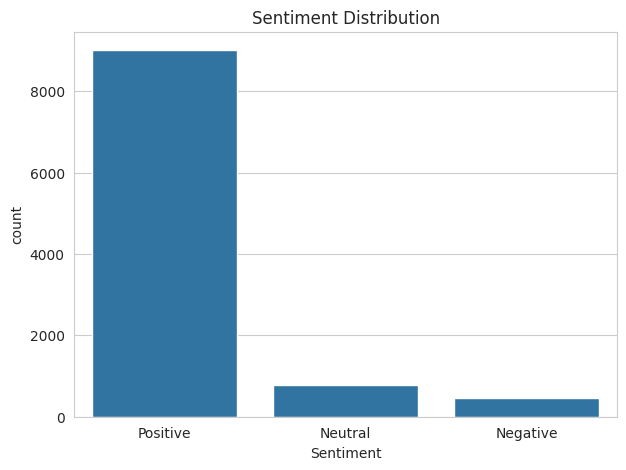

In [80]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sentiment',
    data=df_clean
)

plt.title('Sentiment Distribution')
plt.show()

In [81]:
df_clean['overall'].value_counts()

,count
overall,
5.0,6932
4.0,2083
3.0,772
2.0,250
1.0,217


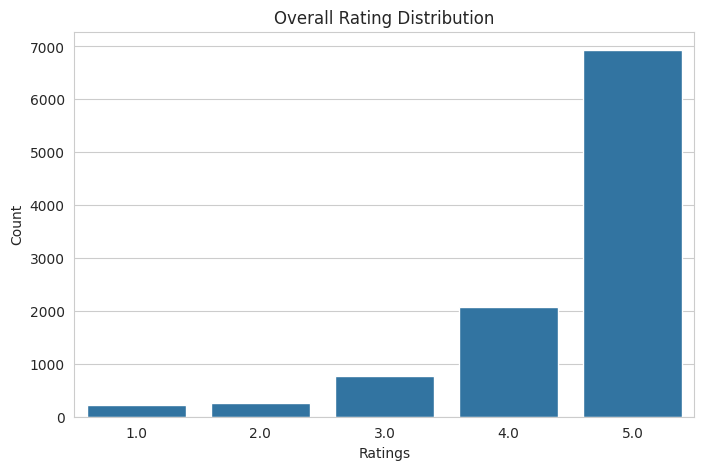

In [82]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='overall',
    data=df_clean
)

plt.title('Overall Rating Distribution')
plt.xlabel('Ratings')
plt.ylabel('Count')

plt.show()

In [83]:
df_clean['review_length'].describe()

,review_length
count,10254.000000
mean,486.260776
std,613.514024
min,9.000000
25%,163.000000
50%,285.000000
75%,552.000000
max,11310.000000


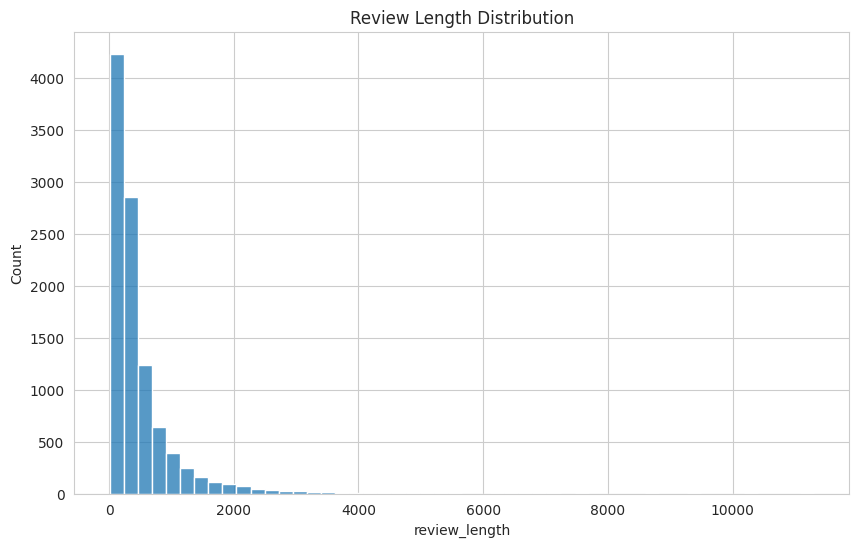

In [84]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean['review_length'],
    bins=50
)

plt.title('Review Length Distribution')

plt.show()

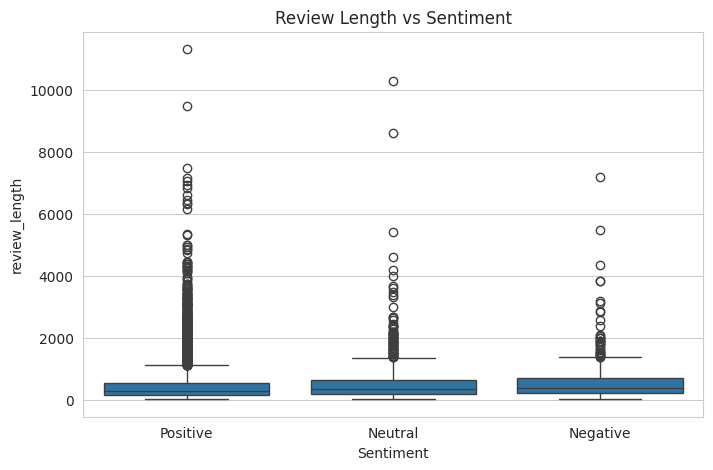

In [85]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment',
    y='review_length',
    data=df_clean
)

plt.title('Review Length vs Sentiment')

plt.show()

In [86]:
df_clean['word_count'].describe()

,word_count
count,10254.000000
mean,90.244880
std,111.249566
min,1.000000
25%,31.000000
50%,54.000000
75%,104.000000
max,2043.000000


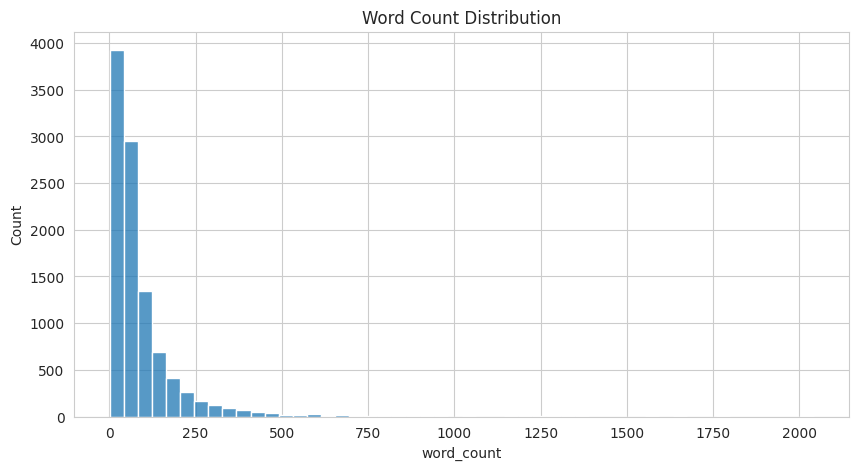

In [87]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_clean['word_count'],
    bins=50
)

plt.title('Word Count Distribution')

plt.show()

In [88]:
df_clean['helpful_score'].describe()

,helpful_score
count,10254.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [89]:
correlation = df_clean[
    ['overall',
     'review_length',
     'word_count',
     'helpful_score']
].corr()

correlation

,overall,review_length,word_count,helpful_score
overall,1.000000,-0.070769,-0.072661,NaN
review_length,-0.070769,1.000000,0.998031,NaN
word_count,-0.072661,0.998031,1.000000,NaN
helpful_score,NaN,NaN,NaN,NaN


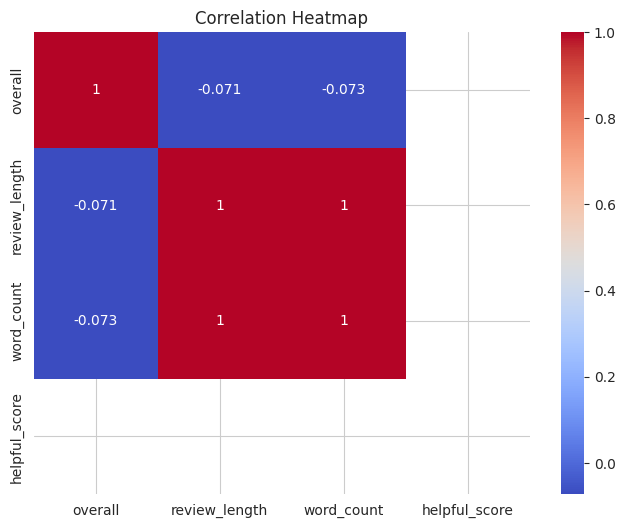

In [90]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [91]:
df_clean['review_year'].value_counts().sort_index()

,count
review_year,
2004,7
2005,4
2006,10
2007,22
2008,63
2009,127
2010,350
2011,1006
2012,1933


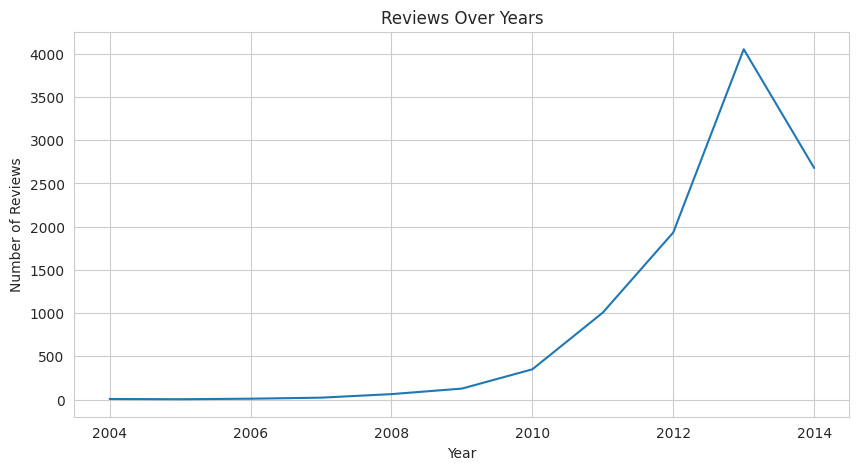

In [92]:
plt.figure(figsize=(10,5))

df_clean['review_year'].value_counts().sort_index().plot(
    kind='line'
)

plt.title('Reviews Over Years')

plt.xlabel('Year')
plt.ylabel('Number of Reviews')

plt.show()

In [94]:
!pip install wordcloud
from wordcloud import WordCloud

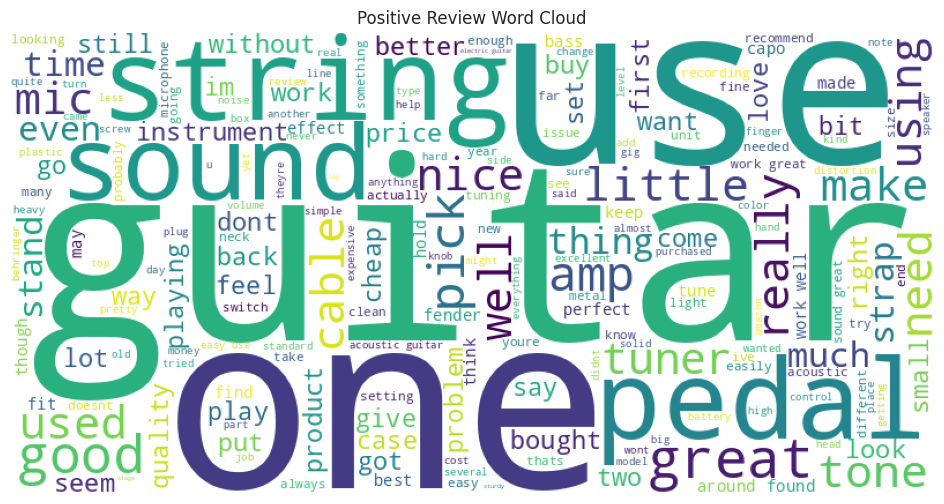

In [95]:
positive_reviews = " ".join(
    df_clean[
        df_clean['Sentiment'] == 'Positive'
    ]['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Positive Review Word Cloud')

plt.show()

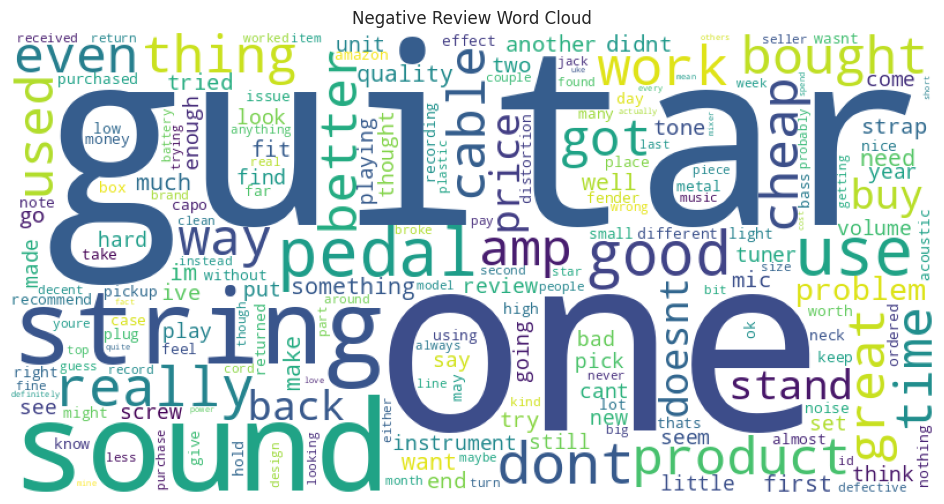

In [96]:
negative_reviews = " ".join(
    df_clean[
        df_clean['Sentiment'] == 'Negative'
    ]['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Negative Review Word Cloud')

plt.show()

In [97]:
from collections import Counter
all_words = " ".join(df_clean['clean_review']).split()

common_words = Counter(all_words).most_common(20)

common_words

[('guitar', 6666),
 ('one', 4761),
 ('sound', 4571),
 ('string', 4570),
 ('great', 3981),
 ('like', 3934),
 ('use', 3714),
 ('good', 3686),
 ('pedal', 3594),
 ('work', 3063),
 ('well', 3023),
 ('get', 2928),
 ('would', 2360),
 ('amp', 2360),
 ('really', 2228),
 ('pick', 2217),
 ('price', 2192),
 ('dont', 2065),
 ('little', 2048),
 ('much', 1967)]

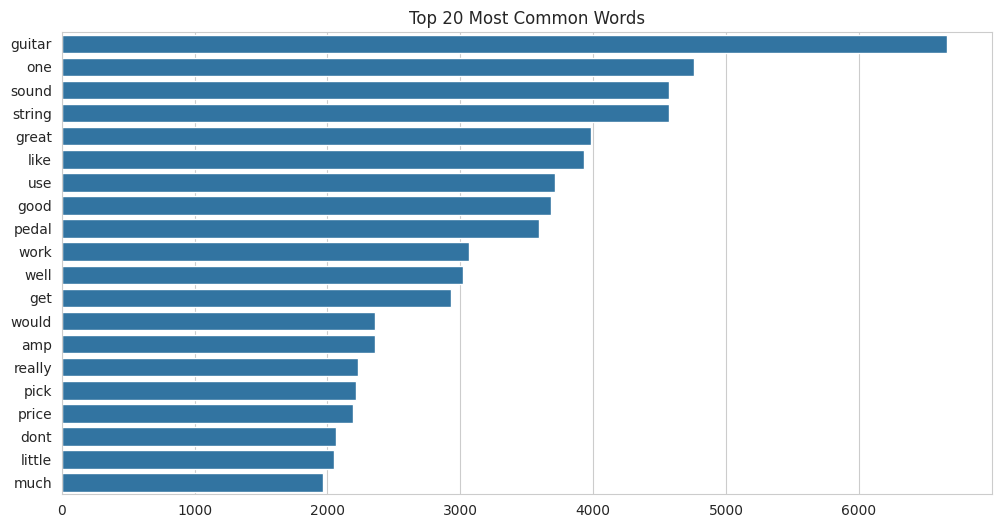

In [98]:
words = [word[0] for word in common_words]

counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title('Top 20 Most Common Words')

plt.show()

In [99]:
plt.savefig('sentiment_distribution.png')

<Figure size 640x480 with 0 Axes>

In [100]:
X = df_clean['clean_review']
y = df_clean['Sentiment']

In [101]:
print(X.head())
print(y.head())

0    much write exactly supposed filter pop sound r...
1    product exactly quite affordablei realized dou...
2    primary job device block breath would otherwis...
3    nice windscreen protects mxl mic prevents pop ...
4    pop filter great look performs like studio fil...
Name: clean_review, dtype: object
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Sentiment, dtype: object


In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000
)

In [103]:
X = tfidf.fit_transform(X)

In [104]:
X.shape

(10254, 5000)

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [106]:
print(X_train.shape)
print(X_test.shape)

(8203, 5000)
(2051, 5000)


In [108]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [109]:
lr_predictions = lr_model.predict(X_test)
print(lr_predictions[:10])

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


In [110]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [111]:
nb_predictions = nb_model.predict(X_test)
print(nb_predictions[:10])

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


In [112]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [113]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8834714773281326


In [114]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.57      0.04      0.07       107
     Neutral       0.00      0.00      0.00       133
    Positive       0.89      1.00      0.94      1811

    accuracy                           0.88      2051
   macro avg       0.49      0.35      0.34      2051
weighted avg       0.81      0.88      0.83      2051



In [115]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

print(lr_cm)

[[   4    0  103]
 [   2    0  131]
 [   1    2 1808]]


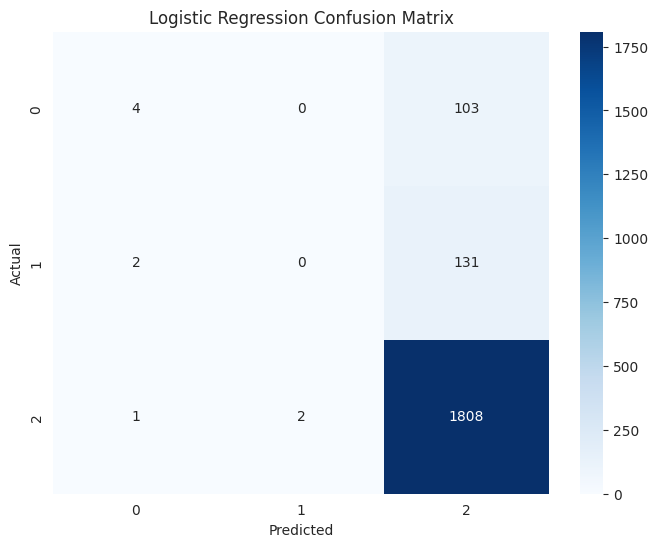

In [116]:
plt.figure(figsize=(8,6))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [117]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8829839102876645


In [118]:
print(
    classification_report(
        y_test,
        nb_predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       107
     Neutral       0.00      0.00      0.00       133
    Positive       0.88      1.00      0.94      1811

    accuracy                           0.88      2051
   macro avg       0.29      0.33      0.31      2051
weighted avg       0.78      0.88      0.83      2051



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


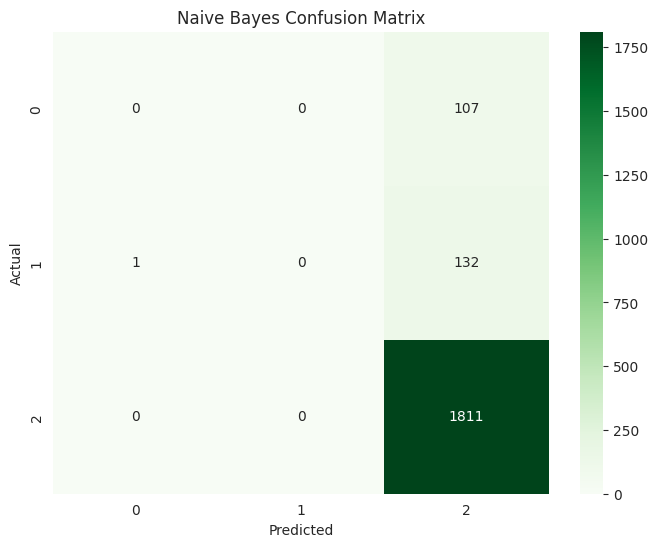

In [120]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)
plt.figure(figsize=(8,6))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Naive Bayes Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

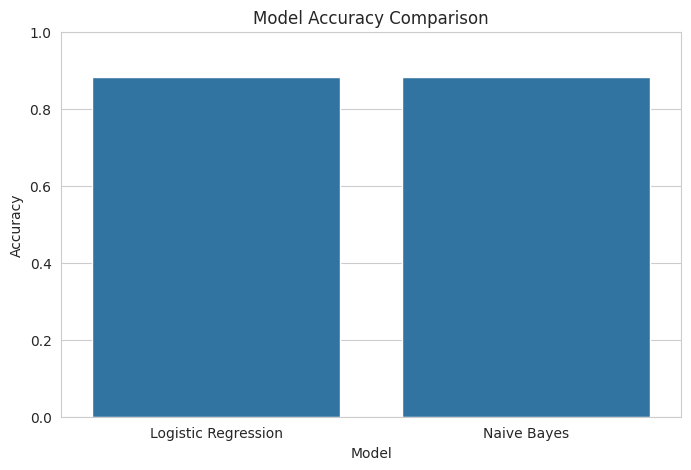

In [121]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],

    'Accuracy': [
        lr_accuracy,
        nb_accuracy
    ]
})

comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Accuracy Comparison')

plt.ylim(0,1)

plt.show()

In [122]:
results = pd.DataFrame({

    'Review': df_clean.loc[y_test.index, 'reviewText'],

    'Actual': y_test,

    'Predicted': lr_predictions
})
wrong_predictions = results[
    results['Actual'] != results['Predicted']
]

wrong_predictions.head(10)

,Review,Actual,Predicted
3610,I bought this strap to use on an acoustic drea...,Neutral,Positive
3949,"I love a lot of Danelectro products, but not r...",Neutral,Positive
7442,I'm sick of protools and I wanted to find some...,Neutral,Positive
5291,Disapointed. The sensors are not providing a c...,Negative,Positive
9766,"Can't hold tightly on 1st string (low C), a li...",Negative,Positive
9758,A three star at best. I was not impressed with...,Neutral,Positive
927,I bought some of these a few years ago just to...,Neutral,Positive
4373,"the effect it self is fine, but it is too nois...",Neutral,Positive
9549,The adjustment screw for the boom is a piece o...,Negative,Positive
4443,I like this preamp. I use one channel for micr...,Neutral,Positive


In [124]:
import pickle

pickle.dump(
    lr_model,
    open('sentiment_model.pkl', 'wb')
)
pickle.dump(
    tfidf,
    open('tfidf_vectorizer.pkl', 'wb')
)